- 作者：东哥起飞

- 首发于[《100天风控专家》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky) 评分卡模型篇-逻辑回归Python代码实操

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import statsmodels as sts
import statsmodels.api as sm
import scorecardpy as sc
import warnings
import sklearn
import toad
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [324]:
# 本代码所涉及算包的版本
print('pandas:',pd.__version__)
print('numpy:',np.__version__)
print('sklearn:',sklearn.__version__)
print('scorecardpy:',sc.__version__)
print('statsmodels',sts.__version__)
print('toad',toad.__version__)

pandas: 2.0.0
numpy: 1.23.5
sklearn: 1.3.2
scorecardpy: 0.1.9.7
statsmodels 0.13.5
toad 0.1.3


In [305]:
# 计算auc和ks
def cal_auc_ks(y_data, y_score):
    from sklearn import metrics
    auc = metrics.roc_auc_score(y_data, y_score)
    if auc < 0.5:
        auc = 1 - auc
    fpr, tpr, the = metrics.roc_curve(y_data, y_score, pos_label=1)
    ks = np.max(np.abs(tpr - fpr))
    for i in range(fpr.shape[0]):
        diff = abs(tpr[i] - fpr[i])
        if diff == ks:
            max_th = the[i]
    return auc, ks, max_th

In [325]:
df = pd.read_excel('huabei_model.xlsx')
df.shape

(50000, 22)

In [326]:
df.head(1)

,sample_id,sample_month,have_car_prob_grade,have_fang_prob_grade,xfdc_index,mobile_fixed_grade,adr_stability_grade,occupation,tot_pay_amt_6m_grade,last_6m_avg_asset_total_grade,ovd_order_cnt_6m_grade,ovd_order_amt_6m_grade,positive_biz_cnt_1y_grade,risk_score,cust_seg,dev_stability_grade,ovd_order_days_6m_grade,first_loan_length_grade,repay_amt_6m_grade,repayment_ability_rank,riskrank,is_dlq_30d
0,1,201802,2,1,7,10,10,不便分类的其他人员（模型预测）,10,5,1,1,10,1,C,D,1,3,9,A,B,0


In [327]:
df['is_dlq_30d'].value_counts()

is_dlq_30d
0    45000
1     5000
Name: count, dtype: int64

In [328]:
df['repayment_ability_rank'] = df['repayment_ability_rank'].map({'A':1,'B':2,'C':3,'D':4})
df['dev_stability_grade'] = df['dev_stability_grade'].map({'A':1,'B':2,'C':3,'D':4})
df['cust_seg'] = df['cust_seg'].map({'A':1,'B':2,'C':3,'D':4})
df['riskrank'] = df['riskrank'].map({'A':1,'B':2,'C':3,'D':4})

# 划分数据集
y_target = 'is_dlq_30d'
col = df.columns.difference(['sample_id','sample_month','occupation',y_target]).tolist()
y = df[y_target]
X_ = df[col]

## 0. LR手动实现

In [329]:
# 创建一个逻辑回归算法的类
class SelfLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def _sigmoid(self, z):
        """Sigmoid 激活函数"""
        return 1 / (1 + np.exp(-z))
    
    def _compute_loss(self, y, y_pred):
        """计算对数损失（log loss）"""
        # 添加小值避免log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    
    def fit(self, X, y):
        """训练模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # 梯度下降
        for _ in range(self.n_iterations):
            # 计算线性组合
            linear_model = np.dot(X, self.weights) + self.bias
            # 应用sigmoid得到预测概率
            y_pred = self._sigmoid(linear_model)
            
            # 计算梯度
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 记录损失
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
    
    def predict_proba(self, X):
        """预测概率"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [330]:
# 数据预处理
scaler = StandardScaler()
X_0 = scaler.fit_transform(X_)

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X_0, y, test_size=0.2, random_state=42)

# 训练模型
model = SelfLogisticRegression(learning_rate=0.1, n_iterations=100)
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

# 评估
cal_auc_ks(y_test, y_pred_prob)

(0.9074490324596824, 0.6790847361914082, 0.21036585977994737)

## 1. LR的Sklearn实现

官方链接：https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [331]:
# 数据预处理
scaler = StandardScaler()
X_1 = scaler.fit_transform(X_)

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X_1, y, test_size=0.2, random_state=42)

# 训练模型
model = LogisticRegression(
    penalty='l2',        # 正则化类型
    C=1.0,               # 正则化强度的倒数
    solver='lbfgs',      # 优化算法
    max_iter=100,        # 最大迭代次数
    random_state=42
)
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # 正类的概率

# 评估
cal_auc_ks(y_test, y_pred_proba)

(0.9138199133202299, 0.6956920538061521, 0.1172771572283287)

参数说明:

**1. penalty: 正则化类型**
- `l1`: L1 正则化（需配合 'liblinear' 或 'saga' solver）
- `l2`: L2 正则化（默认）
- `elasticnet`: L1和L2混合（需配合 'saga' solver）
**2. C: 正则化强度的倒数（越小正则化越强，默认1.0）**

**3. solver: 优化算法**
- liblinear: 适合小数据集（支持L1和L2）
- lbfgs: 适合中等数据集（只支持L2，默认选择）
- sag: 随机平均梯度下降（大数据集）
- saga: sag的改进版（支持所有penalty）
- newton-cg: 牛顿法（适合多分类问题）
**4. multi_class: 多分类处理**
- `ovr`: 一对多策略（默认）
- `multinomial`: 多项损失（需配合 'lbfgs', 'newton-cg', 'sag', 'saga'）

## 2. LR的statsmodels实现

### 1) logit

官方链接：https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

In [332]:
scaler = StandardScaler()
X_2 = scaler.fit_transform(X_)

# 添加截距项（常数项）
X_2 = sm.add_constant(X_2)  # 添加一列1作为截距项

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_2, y,
    test_size=0.2,
    random_state=42
)
# 创建并训练模型
model = sm.Logit(y_train, X_train)  # 使用Logit而不是GLM
result = model.fit()

# 查看详细统计结果
print(result.summary())

# 预测
# 预测概率
y_pred_proba = result.predict(X_test)
# 转换为类别预测（默认阈值0.5）
y_pred = (y_pred_proba >= 0.5).astype(int)

# 评估
cal_auc_ks(y_test, y_pred_proba)

Optimization terminated successfully.
         Current function value: 0.191783
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             is_dlq_30d   No. Observations:                40000
Model:                          Logit   Df Residuals:                    39981
Method:                           MLE   Df Model:                           18
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.4085
Time:                        21:06:36   Log-Likelihood:                -7671.3
converged:                       True   LL-Null:                       -12970.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6618      0.043    -84.195      0.000      -3.747      -3.577
x1            -0.0963      0.

(0.9138218870531345, 0.6955807572006985, 0.11706572850850876)

**result.summary()输出内容**

系数表

- `coef`: 系数估计值
- `std err`: 标准误差
- `z`: z统计量（系数/标准误）
- `P>|z|`: p值（值越小越显著）
- `[0.025 0.975]`: 95%置信区间

模型统计量

- `Log-Likelihood`: 对数似然值
- `LL-Null`: 零模型的对数似然
- `LLR p-value`: 似然比检验的p值
- `Pseudo R-squ.`: 伪R平方

### 2) API公式

官方链接：https://www.statsmodels.org/stable/api.html#module-statsmodels.formula.api

In [333]:
# 使用公式语法
import statsmodels.formula.api as smf
data = pd.DataFrame(X_2[:, 1:], columns=[f"x{i}" for i in range(X_2.shape[1]-1)])
data['y'] = y

formula = 'y ~ ' + ' + '.join([f"x{i}" for i in range(X_2.shape[1]-1)])
model = smf.logit(formula, data=data)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.194121
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                50000
Model:                          Logit   Df Residuals:                    49981
Method:                           MLE   Df Model:                           18
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.4029
Time:                        21:09:07   Log-Likelihood:                -9706.1
converged:                       True   LL-Null:                       -16254.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6473      0.039    -94.234      0.000      -3.723      -3.571
x0            -0.0822      0.

In [334]:
# # 获取系数置信区间
print("\n95%置信区间:")
print(result.conf_int())

# # 获取odds ratio及其置信区间
print("\nOdds Ratios:")
print(np.exp(result.params))
print("\nOdds Ratios 95%置信区间:")
print(np.exp(result.conf_int()))


95%置信区间:
                  0         1
Intercept -3.723175 -3.571455
x0        -0.132211 -0.032091
x1         0.524150  0.685633
x2        -0.013041  0.061152
x3         0.060466  0.154144
x4        -0.088280 -0.004096
x5        -0.076352  0.015771
x6        -0.251022 -0.108553
x7        -0.060006  0.022920
x8        -0.102508 -0.036315
x9         0.087173  0.150232
x10        0.263549  0.333495
x11       -0.212684 -0.121509
x12        0.437932  0.552569
x13       -0.114512 -0.024737
x14        0.871519  1.002952
x15        0.575711  0.687355
x16        0.131015  0.226465
x17       -0.069024  0.004283

Odds Ratios:
Intercept    0.026061
x0           0.921133
x1           1.831053
x2           1.024348
x3           1.113274
x4           0.954862
x5           0.970163
x6           0.835448
x7           0.981628
x8           0.932942
x9           1.126035
x10          1.347865
x11          0.846118
x12          1.640909
x13          0.932744
x14          2.552915
x15          1.880491
x1

### 3) GLM支持正则化

官方链接：https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html

In [335]:
# 使用GLM实现带正则化的逻辑回归
model = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial(),
    # 使用elastic net正则化
    alpha=0.5  # 0为L2，1为L1，中间值为混合
)
result = model.fit_regularized()

# 预测概率
y_pred_proba = result.predict(X_test)
# 转换为类别预测（默认阈值0.5）
y_pred = (y_pred_proba >= 0.5).astype(int)

# 评估
cal_auc_ks(y_test, y_pred_proba)

(0.9138215580976505, 0.6955807572006985, 0.1170645915410879)

## 3. sklearn和statsmodels对比

|     对比项   | statsmodels |         scikit-learn |
| :--------- | :--: | -----------: |
| 主要用途     |  统计分析  |     机器学习预测 |
| 输出重点   |  系数统计显著性  |   预测准确率 |
| API风格 |  类似R的公式语法  | 统一的fit/predict接口 |
| 正则化支持 |  有限(需用GLM+fit_regularized)  | 完善 |
| 大数据集处理 |  较差  | 优化更好 |
| 可视化支持 |  有限  | 需配合其他库 |

## 4. 其他评分卡包-toad

官方链接：https://toad.readthedocs.io/en/stable/tutorial_chinese.html

In [336]:
# 划分训练测试集
train, test = train_test_split(
    df[col+[y_target]],
    test_size=0.2,
    random_state=42
)

# WOE转换
transformer = toad.transform.WOETransformer()
train_woe = transformer.fit_transform(
    train, 
    train[y_target],
    exclude=[y_target]
)
test_woe = transformer.transform(test)

# 使用sklearn拟合逻辑回归
lr = LogisticRegression()
lr.fit(train_woe[col], train[y_target])

# 模型评估
# 训练集评估
train_pred = lr.predict_proba(train_woe[col])[:, 1]
print("\nTrain AUC:", toad.metrics.AUC(train_pred, train[y_target]))

# 测试集评估
test_pred = lr.predict_proba(test_woe[col])[:, 1]
print("Test AUC:", toad.metrics.AUC(test_pred, test[y_target]))

# 8. 输出模型系数
coef_df = pd.DataFrame({
    'feature': ['intercept'] + col,
    'coefficient': [lr.intercept_[0]] + list(lr.coef_[0])
})
print("\nModel coefficients:")
print(coef_df)


Train AUC: 0.9174600643012435
Test AUC: 0.9094300023849272

Model coefficients:
                          feature  coefficient
0                       intercept    -2.190549
1             adr_stability_grade     0.156898
2                        cust_seg     0.334138
3             dev_stability_grade    -0.015212
4         first_loan_length_grade    -0.500029
5             have_car_prob_grade    -0.298153
6            have_fang_prob_grade    -0.041366
7   last_6m_avg_asset_total_grade     0.032418
8              mobile_fixed_grade     0.094243
9          ovd_order_amt_6m_grade    -0.154088
10         ovd_order_cnt_6m_grade     0.230570
11        ovd_order_days_6m_grade     0.433431
12      positive_biz_cnt_1y_grade     0.010513
13             repay_amt_6m_grade    -1.297004
14         repayment_ability_rank    -0.349942
15                     risk_score     0.466022
16                       riskrank     0.467592
17           tot_pay_amt_6m_grade    -0.717304
18                     xfd

In [337]:
cal_auc_ks(train[y_target], train_pred)

(0.9174600643012435, 0.687384334319086, 0.10125745646052815)

In [338]:
cal_auc_ks(test[y_target], test_pred)

(0.9094300023849272, 0.6798610711338822, 0.07943854585377753)

## 5. 其他评分卡包-scorecardpy

官方链接：https://shichen.name/scorecard/

In [339]:
# 数据集划分
train, test = sc.split_df(df[col+[y_target]], y_target, ratio=0.7, seed=42).values()

# 变量分箱
bins = sc.woebin(df[col+[y_target]], y=y_target, method='tree')

# WOE转换
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

col_woe = train_woe.drop(y_target, axis=1).columns.tolist()

# 使用sklearn拟合逻辑回归
lr = LogisticRegression()
lr.fit(train_woe[col_woe], train[y_target])

# 模型评估
# 训练集评估
train_pred = lr.predict_proba(train_woe[col_woe])[:, 1]
test_pred  = lr.predict_proba(test_woe[col_woe])[:, 1]

[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [343]:
cal_auc_ks(train[y_target], train_pred)

(0.9170845986394557, 0.6871111111111111, 0.09559446631530157)

In [344]:
cal_auc_ks(test[y_target], test_pred)

(0.9101869629629629, 0.6819999999999999, 0.09759650550250473)

## 番外

如果对pandas不熟悉想要进阶的朋友可以了解下东哥的这个原创笔记，已经完全体，后续随着版本迭代会持续更新。

[《pandas进阶宝典》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)永久访问权限，500页图文笔记，近30万字，配套完整代码支持下载。

5大核心图文，具体包括：
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

感兴趣可以扫码了解，或者加我微信可以有折扣，加V：`Petery_1966`

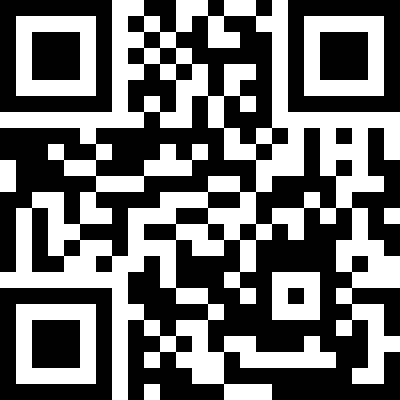